In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

td(0) semi gradient descent neural network function approximation

In [2]:
class ValueFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d)
        self.sig1 = nn.Sigmoid()
        self.fc2 = nn.Linear(d, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)

        return x

In [4]:
EPISODES = 250000
GAMMA = 1.0
ALPHA = 0.05
LAYER2 = 10

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]
def x(s1, s2, s3):
    ps, ds = s1 / 20.0, s2 / 9.0
    return np.array([1.0, ps, ds, float(s3), ps * ds, ps * s3])
def policy(s1, s2, s3):
    if (2 <= s2+1 <= 6 and s3 == 0 and s1+1 <= 12): #no ace, player sum 11-
        return 1
    if ((s2+1 >= 7 or s2+1 == 1) and s3 == 0 and s1+1 <= 16): #dealer 7+, no ace, player sum 16-
        return 1
    if (s3 == 1 and s1+1 <=18): #have usable ace, player sum 18-
        return 1
    return 0

#init w
# w = np.zeros(6) #1, playersum, dealersum, ace, sumxdealer, sumxace

wins = []

model = ValueFcnApprox(6, LAYER2)
optimizer = torch.optim.SGD(model.parameters(), lr=ALPHA)

#for episode in episodes
for episode in range(EPISODES):
    s, _ = env.reset()
    s1, s2, s3 = state_to_idx(s)

    #loop thru episode
    while True:
        #get a from policy and see next state, reward
        a = policy(s1, s2, s3)
        s_n, r, term, trunc, _ = env.step(a)
        s1_n, s2_n, s3_n = state_to_idx(s_n)
        
        #forward
        xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
        v = model(xi).squeeze()


        if term or trunc:
            wins.append(r > 0)
            #target
            target = torch.tensor(r, dtype=torch.float32)
            
            #loss
            loss = (target - v)**2
            
            #backprop
            optimizer.zero_grad()
            loss.backward()
            
            #terminal update
            optimizer.step()
            break
        #update nn
        #forward
        xi_n = torch.tensor(x(s1_n, s2_n, s3_n), dtype=torch.float32)
        with torch.no_grad():
            v_n = model(xi_n).squeeze()
        target = r + GAMMA * v_n
        
        #get loss
        loss = (target - v)**2
        #backprop
        optimizer.zero_grad()
        loss.backward()
        #update
        optimizer.step()

        s1, s2, s3 = s1_n, s2_n, s3_n
    




env.close()

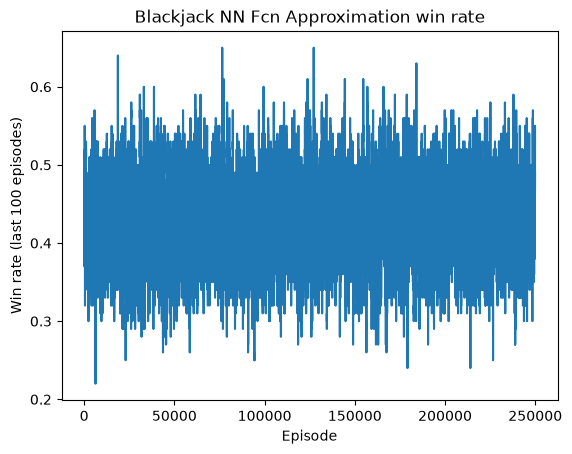

In [5]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack NN Fcn Approximation win rate')
plt.show()

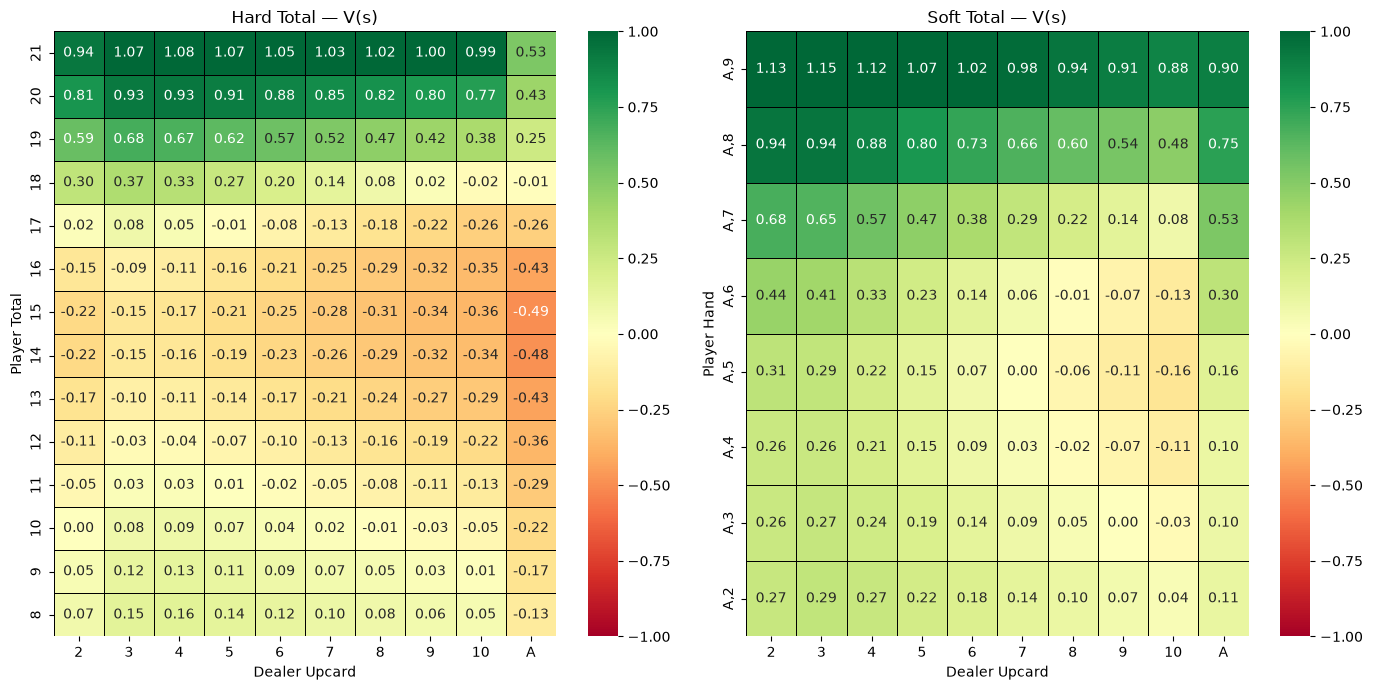

In [6]:
dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

def v_hat(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
    with torch.no_grad():
        return model(xi).squeeze().item()

hard_table = []
soft_table = []

for player_sum in range(8, 22):
    for dealer_up, dealer_label in dealer_upcards:
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Hard Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Soft Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()